# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../../lectures/lecture02/lecture02.md), [демо](../../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ (а).**

1. **Выпукло.** Это надграфик функции $x_1^2$, выпуклой на $\mathbb{R}$ ($f'' = 2 > 0$), а надграфик выпуклой функции выпукл (раздел 3). Другой путь: множество $\{x_1^2 - x_2 \le 0\}$ — подуровневое множество выпуклой функции $x_1^2 - x_2$ (сумма выпуклой и аффинной).

2. **Выпукло.** Функция $\varphi(x) = \Vert Ax - b\Vert_2$ выпукла как норма от аффинного отображения (операция 2 раздела 5), а множество — её подуровневое множество $\{\varphi \le 1\}$. Равносильно: это аффинный прообраз единичного шара $\{z : \Vert z - b\Vert \le 1\}$ при отображении $x \mapsto Ax$, а аффинные прообразы выпуклых множеств выпуклы (раздел 2). Никаких условий на $A$ и $b$ не нужно (множество может оказаться пустым — пустое множество тоже выпукло).

3. **Не выпукло.** Точки $(1, 0)$ и $(-1, 0)$ лежат в множестве ($\Vert x\Vert = 1$), а их середина $(0, 0)$ — нет ($\Vert 0\Vert = 0 < 1$). Внешность шара — стандартный пример из чек-листа: $h(x) = \Vert x\Vert^2 - 1$ не вогнута, и множество действительно не выпукло.

**(б)**

**Ответ (б).**

1. Функция квадратичная: $f(x) = \tfrac12 x^\top Q x$ с $Q = \begin{pmatrix} 2 & a \\ a & 2\end{pmatrix}$ (гессиан постоянен и равен $Q$). Собственные числа $Q$ — корни $(2 - \lambda)^2 = a^2$, то есть $\lambda = 2 \pm a$. Критерий второго порядка: $f$ выпукла $\iff Q \succeq 0 \iff 2 - |a| \ge 0 \iff |a| \le 2$; строго выпукла при $Q \succ 0$, то есть при $|a| < 2$. На границе $a = \pm 2$ имеем $f = (x_1 \pm x_2)^2$: выпукла, но не строго — она равна нулю на целой прямой $x_1 = \mp x_2$.

2. **Не выпукла.** Контрпример хордой: $g(1, 0) = g(0, 1) = 0$, а в середине $g(\tfrac12, \tfrac12) = \tfrac1{16} > 0 = $ значение хорды. Через гессиан: $\nabla^2 g = \begin{pmatrix} 2x_2^2 & 4x_1 x_2 \\ 4x_1 x_2 & 2x_1^2\end{pmatrix}$, его определитель $4x_1^2x_2^2 - 16x_1^2x_2^2 = -12\,x_1^2 x_2^2 < 0$ при $x_1 x_2 \ne 0$ — гессиан индефинитен почти всюду. Заметьте: вдоль каждой координатной оси и вдоль диагоналей $g$ выпукла ($t^4$ и $0$), поэтому «проверка по нескольким направлениям» здесь обманывает.

In [2]:
for a in (0.0, 1.5, 2.0, 2.5, -2.0, -3.0):
    lam = np.linalg.eigvalsh(np.array([[2.0, a], [a, 2.0]]))
    verdict = "строго выпукла" if lam.min() > 1e-12 else ("выпукла, не строго" if lam.min() > -1e-12 else "НЕ выпукла")
    print(f"a = {a:5.1f}: собственные числа Q = {lam.round(3)}  ->  {verdict}")

g = lambda x: x[0] ** 2 * x[1] ** 2
x, y = np.array([1.0, 0.0]), np.array([0.0, 1.0])
print("\ng(x) = %.3f, g(y) = %.3f, хорда в середине = %.3f, g(середины) = %.4f  -> хорда ПОД графиком, не выпукла"
      % (g(x), g(y), 0.5 * (g(x) + g(y)), g(0.5 * (x + y))))
H = lambda x: np.array([[2 * x[1] ** 2, 4 * x[0] * x[1]], [4 * x[0] * x[1], 2 * x[0] ** 2]])
print("собственные числа гессиана g в (1, 1):", np.linalg.eigvalsh(H([1.0, 1.0])).round(3))

a =   0.0: собственные числа Q = [2. 2.]  ->  строго выпукла
a =   1.5: собственные числа Q = [0.5 3.5]  ->  строго выпукла
a =   2.0: собственные числа Q = [0. 4.]  ->  выпукла, не строго
a =   2.5: собственные числа Q = [-0.5  4.5]  ->  НЕ выпукла
a =  -2.0: собственные числа Q = [0. 4.]  ->  выпукла, не строго
a =  -3.0: собственные числа Q = [-1.  5.]  ->  НЕ выпукла

g(x) = 0.000, g(y) = 0.000, хорда в середине = 0.000, g(середины) = 0.0625  -> хорда ПОД графиком, не выпукла
собственные числа гессиана g в (1, 1): [-2.  6.]


**(в)**

**Ответ (в).**

1. **Выпукла.** $\Vert Ax - b\Vert_2$ — норма от аффинного отображения (операция 2), $\Vert x\Vert_\infty$ — норма; неотрицательная взвешенная сумма выпуклых функций выпукла (операция 1). **Негладкая**: обе нормы не дифференцируемы ($\ell_2$ — в нуле невязки, $\ell_\infty$ — там, где максимальная по модулю координата меняется).

2. **Выпукла.** Каждая функция $(a_i^\top x - b_i)^2$ — выпуклая $u^2$ от аффинной $u = a_i^\top x - b_i$ (операция 2), то есть квадратичная с $Q = 2a_i a_i^\top \succeq 0$. Поточечный максимум выпуклых функций выпукл (операция 3). **Негладкая**: изломы там, где два квадрата невязок равны и «лидер» меняется. (Правило композиции 4 здесь не нужно — и не сработало бы: $u^2$ не монотонна.)

3. **Не выпукла.** Это композиция $g(u) = e^{-u}$ с $u(x) = \Vert x\Vert^2$: внутренняя выпукла, внешняя выпукла, но **убывает**, поэтому правило 4 не применимо — и вывод сделать нельзя. Контрпример: $f(e_1) = f(-e_1) = e^{-1} \approx 0.37$, а в середине $f(0) = 1$ — хорда под графиком. Это «горб» (перевёрнутая гауссиана). Функция при этом **гладкая** ($C^\infty$) — единственная гладкая из трёх, и единственная невыпуклая: гладкость и выпуклость — независимые свойства.

**(г)**

**Ответ (г).** Чек-лист раздела 6: цель выпукла? равенства аффинны? неравенства $h_i \ge 0$ с вогнутыми $h_i$?

| Задача ДЗ 1 | Выпукла? | Почему |
|---|---|---|
| (а) ближайшая точка прямой | **да** | цель $\tfrac12\Vert x - p\Vert^2$ квадратичная с $Q = I \succ 0$; два аффинных равенства; неравенств нет. Выпуклая QP, решение единственно |
| (б) диета | **да** | LP: линейная цель, линейные неравенства $Ax \ge b$, $x \ge 0$ — всё аффинно |
| (в) прямоугольник в круге | **нет** | $\max\, 4x_1x_2 \iff \min\, -x_1 x_2$: гессиан цели $\begin{pmatrix} 0 & -1 \\ -1 & 0\end{pmatrix}$ имеет собственные числа $\pm 1$ — индефинитен, цель не выпукла. Если вершину требовать на окружности, ломается и второе условие: $x_1^2 + x_2^2 = 1$ — нелинейное равенство |
| (г) подгонка $x_1 \sin(x_2 t + x_3)$ | **нет** | цель периодична по $x_3$ с периодом $2\pi$; непрерывная периодическая функция ограничена, а выпуклая функция, ограниченная сверху на всей прямой, постоянна (касательная — глобальная нижняя оценка, с ненулевым наклоном она ушла бы в $+\infty$). Кроме того, $(x_1, x_3) \to (-x_1, x_3 + \pi)$ даёт вторую копию каждого минимума, а множество решений выпуклой задачи должно быть выпуклым |
| (д) чебышёвская подгонка $\max_i \lvert a_i^\top x - b_i\rvert$ | **да** | максимум модулей аффинных функций — выпукла (упражнение 12.3б), негладкая; после slack-переформулировки из ДЗ 1 — LP |

Итог: три задачи из пяти выпуклы, и именно для них любой найденный `minimize`/`linprog` локальный минимум автоматически глобален. Для (в) и (г) ответ солвера зависит от старта — см. задачу 2(б).

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ (а), пункт 1.** Обозначим $f(x) = \tfrac12\Vert x - p\Vert^2$, $\nabla f(x) = x - p$. Задача выпукла (строго выпуклая цель, полупространство — выпуклое множество), поэтому условие оптимальности необходимо и достаточно, а решение единственно.

*(i) Решение на границе.* Если бы $a^\top x^\ast < b$, точка $x^\ast$ была бы внутренней: направления $y - x^\ast$ есть во все стороны, и условие превращается в $\nabla f(x^\ast) = 0$, то есть $x^\ast = p$. Но $p \notin \Omega$ — противоречие. Значит, $a^\top x^\ast = b$.

*(ii) Направление $x^\ast - p$.* Пусть $a^\top v = 0$. Тогда $a^\top(x^\ast \pm v) = b$, обе точки допустимы, и условие даёт $(x^\ast - p)^\top v \ge 0$ и $(x^\ast - p)^\top(-v) \ge 0$, то есть $(x^\ast - p)^\top v = 0$ для всех $v \perp a$. Вектор, ортогональный всему ортогональному дополнению $a$, коллинеарен $a$: $x^\ast - p = -\tau a$ при некотором $\tau \in \mathbb{R}$.

*(iii) Коэффициент.* $b = a^\top x^\ast = a^\top p - \tau\Vert a\Vert^2$, откуда $\tau = \dfrac{a^\top p - b}{\Vert a\Vert^2} > 0$ и $x^\ast = p - \tau a$ — искомая формула.

*(iv) Достаточность.* Для любого $y \in \Omega$: $(x^\ast - p)^\top(y - x^\ast) = -\tau\, a^\top(y - x^\ast) = -\tau\,(a^\top y - b) \ge 0$, поскольку $a^\top y \le b$ и $\tau > 0$. Условие выполнено, по теореме раздела 7 точка $x^\ast$ — глобальное решение. Геометрия: $p - x^\ast = \tau a$ — мы сдвинулись из $p$ против нормали ровно до гиперплоскости. Если бы $a^\top p \le b$, проекцией была бы сама точка $p$; общая формула — $x^\ast = p - \max(0, a^\top p - b)\,a/\Vert a\Vert^2$.

**Численная проверка (пункты 2 и 3)**

In [4]:
f = lambda x: 0.5 * np.sum((x - p) ** 2)
df = lambda x: x - p

x_formula = p - (a @ p - b) / (a @ a) * a
res = minimize(f, x0=np.zeros(3), jac=df, method="SLSQP",
               constraints=[{"type": "ineq", "fun": lambda x: b - a @ x, "jac": lambda x: -a}])
print("формула:", x_formula.round(6))
print("SLSQP:  ", res.x.round(6), "  расхождение %.1e" % np.abs(res.x - x_formula).max())
print("a^T x* - b = %.1e  (решение на границе)" % (a @ x_formula - b))

# случайные допустимые y: берём точки куба и оставляем те, что удовлетворяют a^T y <= b
Y = rng.uniform(-4, 4, (6000, 3))
Y = Y[Y @ a <= b]
print("допустимых точек:", len(Y))

def check(x, label):
    vals = (Y - x) @ df(x)
    print(f"{label}: min по y  grad^T (y - x) = {vals.min(): .4f}  ->  {'условие выполнено' if vals.min() >= -1e-8 else 'НАРУШЕНО: есть допустимое направление убывания'}")

check(x_formula, "x* по формуле")
check(np.zeros(3), "x = 0        ")

формула: [ 2.416667 -0.166667  1.083333]
SLSQP:   [ 2.416667 -0.166667  1.083333]   расхождение 6.7e-16
a^T x* - b = -4.4e-16  (решение на границе)
допустимых точек: 3375
x* по формуле: min по y  grad^T (y - x) =  0.0009  ->  условие выполнено
x = 0        : min по y  grad^T (y - x) = -13.8414  ->  НАРУШЕНО: есть допустимое направление убывания


**Ответ (а), пункты 2–3.** `SLSQP` возвращает ту же точку, что формула (расхождение $\sim 10^{-15}$). В $x^\ast$ минимум величины $\nabla f(x^\ast)^\top(y - x^\ast)$ по случайным допустимым $y$ неотрицателен (небольшое положительное число — потому что случайные $y$ не попадают точно на гиперплоскость, где условие обращается в равенство): ни в одном допустимом направлении $f$ не убывает, точка сертифицирована как решение без знания «истинного» ответа. В точке $x = 0$ минимум отрицательный: найдено допустимое направление, вдоль которого $f$ убывает в первом порядке, — точка не оптимальна, и это направление указывает, куда идти.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

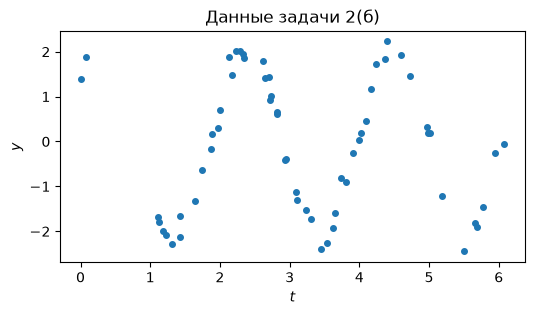

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ (б), пункт 1.**

**Модель B — линейный МНК, выпуклая задача.** $\varphi_B$ линейна по параметрам: $\varphi_B(t_i; x) = M_i x$, где строка $M_i = (\sin\omega t_i,\ \cos\omega t_i)$. Поэтому $f(x) = \tfrac12\Vert Mx - y\Vert^2 = \tfrac12 x^\top (M^\top M)x - y^\top M x + \tfrac12 y^\top y$ — квадратичная с $Q = M^\top M \succeq 0$: безусловная выпуклая QP. Столбцы $M$ (синус и косинус на 60 точках) линейно независимы, так что $Q \succ 0$ и $f$ строго выпукла — решение единственно и находится из нормальных уравнений (или любым методом из любого старта).

**Модель A — нелинейный МНК, невыпуклая NLP.** Модель нелинейна по $x_2$ и $x_3$, так что $f$ не квадратична. Невыпуклость видна из симметрий: $f(x_1, x_2, x_3 + 2\pi) = f(x)$ — функция периодична по $x_3$. Непрерывная периодическая функция ограничена, а выпуклая функция, ограниченная сверху на всей прямой, постоянна (по критерию первого порядка касательная — глобальная нижняя оценка; при ненулевом наклоне она уходит в $+\infty$ в одну из сторон). Так как $f$ по $x_3$ не постоянна, она не выпукла. Вторая симметрия, $(x_1, x_3) \to (-x_1, x_3 + \pi)$, и знак частоты $(x_2, x_3) \to (-x_2, \pi - x_3)$ дают несколько изолированных копий каждого минимума — а множество решений выпуклой задачи обязано быть выпуклым (упражнение 12.5а).

**Мультистарт (пункт 2)**

модель A: f по стартам = [ 1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14 61.5
 61.5  61.5  61.5  61.69 63.82 63.82 64.25 64.25]
модель B: f по стартам = [1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408
 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408]

доля стартов в наименьшем найденном минимуме: A = 0.55,  B = 1.00
модель B: разброс решений по координатам = [2.4e-07 2.7e-07]  -> одна точка
модель B: x* = [1.6234 1.3378]  -> амплитуда 2.1036, фаза 0.6892 (истина: 2, 0.7)
модель A: лучшее решение (амплитуда, частота, фаза) = [-2.1014  2.9967 -2.4413]


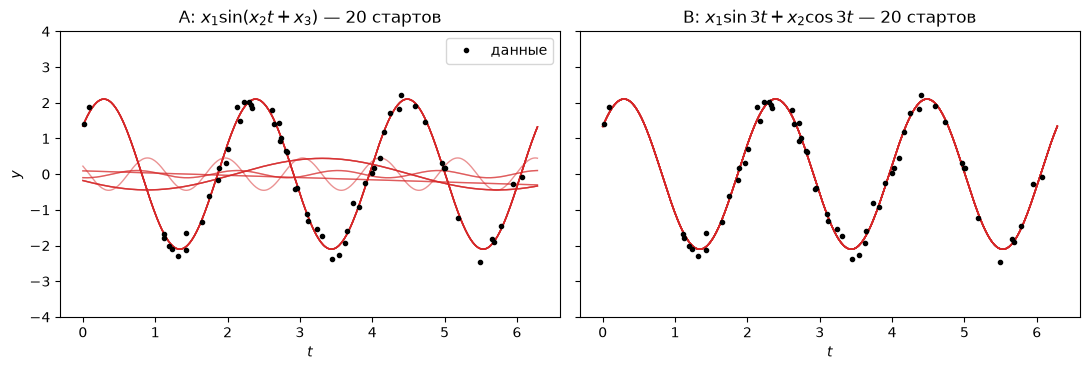

In [6]:
import warnings

fA = lambda x: 0.5 * np.sum((x[0] * np.sin(x[1] * t + x[2]) - y) ** 2)
fB = lambda x: 0.5 * np.sum((x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t) - y) ** 2)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    resA = [minimize(fA, x0, method="BFGS") for x0 in starts]
    resB = [minimize(fB, x0[:2], method="BFGS") for x0 in starts]

fvalA = np.array([r.fun for r in resA]); fvalB = np.array([r.fun for r in resB])
print("модель A: f по стартам =", np.sort(fvalA).round(2))
print("модель B: f по стартам =", np.sort(fvalB).round(4))
tol = 1e-3
print(f"\nдоля стартов в наименьшем найденном минимуме: A = {np.mean(fvalA < fvalA.min() * (1 + tol)):.2f},  B = {np.mean(fvalB < fvalB.min() * (1 + tol)):.2f}")
xB = np.array([r.x for r in resB])
print("модель B: разброс решений по координатам =", np.ptp(xB, axis=0).round(8), " -> одна точка")
print("модель B: x* =", xB[0].round(4), " -> амплитуда %.4f, фаза %.4f (истина: 2, 0.7)" % (np.hypot(*xB[0]), np.arctan2(xB[0][1], xB[0][0])))
best = min(resA, key=lambda r: r.fun)
print("модель A: лучшее решение (амплитуда, частота, фаза) =", best.x.round(4))

tt = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for r in resA:
    axes[0].plot(tt, r.x[0] * np.sin(r.x[1] * tt + r.x[2]), color="C3", lw=1, alpha=0.5)
for r in resB:
    axes[1].plot(tt, r.x[0] * np.sin(omega * tt) + r.x[1] * np.cos(omega * tt), color="C3", lw=1, alpha=0.5)
for ax, title in zip(axes, ("A: $x_1 \\sin(x_2 t + x_3)$ — 20 стартов", "B: $x_1 \\sin 3t + x_2 \\cos 3t$ — 20 стартов")):
    ax.plot(t, y, "o", color="k", ms=3, label="данные"); ax.set(title=title, xlabel="$t$", ylim=(-4, 4))
axes[0].set_ylabel("$y$"); axes[0].legend(loc="upper right")
plt.tight_layout(); plt.show()

**Объяснение (пункт 3)**

**Ответ (б), пункт 3.** Для модели B все 20 стартов дали одну и ту же точку с одним и тем же $f$: задача выпукла (строго), по главной теореме лекции её единственный локальный минимум глобален, и старт влиял только на число итераций. Для модели A лишь около половины стартов пришли в глобальный минимум ($f \approx 1.1$); остальные застряли в локальных минимумах с неверной частотой ($f \approx 60$–$65$ — кривая почти не следует за данными). Метод один и тот же — BFGS; разница только в выпуклости задачи.

**Связь решений.** По формуле синуса суммы $x_1\sin(\omega t + x_3) = (x_1\cos x_3)\sin\omega t + (x_1 \sin x_3)\cos\omega t$, поэтому решение B $(x_1^B, x_2^B)$ даёт для A амплитуду $\sqrt{(x_1^B)^2 + (x_2^B)^2} \approx 2.10$ и фазу $\operatorname{atan2}(x_2^B, x_1^B) \approx 0.69$ — совпадает с лучшим решением A с точностью до симметрии: BFGS нашёл $(-2.10,\ 3.00,\ -2.44)$, а $-2.10\sin(3t - 2.44) = 2.10\sin(3t - 2.44 + \pi) = 2.10 \sin(3t + 0.70)$.

**Почему у A минимум чуть ниже и почему это не «лучше».** Модель B — это модель A с закреплённой частотой $\omega = 3$, то есть A минимизирует по большему множеству и её глобальный минимум не выше: лишняя степень свободы подстраивается под шум. Но этот минимум A нашла лишь из части стартов, и, не зная ответа заранее, мы не могли бы отличить правильный запуск от неправильного — только сравнением $f$ между запусками. Выпуклая B даёт гарантированный ответ из любого старта. Практический рецепт для таких задач: если что-то (частоту) удаётся закрепить или оценить отдельно — решить выпуклую подзадачу и лишь потом уточнять невыпуклую, стартуя из её решения.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ.** Условие оптимальности для проекции (раздел 7, пример 2): $(P(p) - p)^\top (y - P(p)) \ge 0$ для всех $y \in \Omega$. Подставим $y = P(q) \in \Omega$; затем то же для $P(q)$ с $y = P(p)$:

$$(P(p) - p)^\top\big(P(q) - P(p)\big) \ge 0, \qquad (P(q) - q)^\top\big(P(p) - P(q)\big) \ge 0 .$$

Сложим (во втором меняем знак множителя, чтобы оба содержали $P(q) - P(p)$): $\big[(P(p) - p) - (P(q) - q)\big]^\top \big(P(q) - P(p)\big) \ge 0$, то есть

$$\Vert P(p) - P(q)\Vert^2 \le (p - q)^\top\big(P(p) - P(q)\big) \le \Vert p - q\Vert \cdot \Vert P(p) - P(q)\Vert$$

по Коши–Буняковскому. Если $P(p) \ne P(q)$, делим на $\Vert P(p) - P(q)\Vert$ и получаем требуемое; если равны — неравенство тривиально. Проекция на выпуклое множество — нерастягивающее отображение; на этом держится сходимость метода проекции градиента (часть IV). Численно максимум отношения $\Vert P(p) - P(q)\Vert / \Vert p - q\Vert$ на 1000 случайных парах равен ровно $1$ и для шара, и для куба (пары точек, лежащих внутри множества, проецируются в себя) — и ни разу его не превышает.

In [7]:
P_ball = lambda z: z / max(1.0, np.linalg.norm(z))
P_box = lambda z: np.clip(z, -1.0, 1.0)
for name, P in (("шар", P_ball), ("куб", P_box)):
    U = rng.uniform(-3, 3, (1000, 3)); V = rng.uniform(-3, 3, (1000, 3))
    num = np.linalg.norm(np.array([P(u) - P(v) for u, v in zip(U, V)]), axis=1)
    den = np.linalg.norm(U - V, axis=1)
    print(f"{name}: max |P(p) - P(q)| / |p - q| = {(num / den).max():.4f}  (<= 1: проекция не растягивает)")

шар: max |P(p) - P(q)| / |p - q| = 1.0000  (<= 1: проекция не растягивает)
куб: max |P(p) - P(q)| / |p - q| = 1.0000  (<= 1: проекция не растягивает)


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../../CONTRIBUTING.md).